## All Imports

In [ ]:
# data extraction and cleaning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# For exporting the model
import joblib
import os
print("Libraries imported successfully!")

Libraries imported successfully!


## Code for data extraction and cleaning

In [ ]:
# Data loading

file_path = 'data/Student_Performance.csv'

# Read the CSV file into our DataFrame 'df'
df = pd.read_csv(file_path)

# .head() shows us the first 5 rows so we can make sure it loaded correctly
print("First 5 rows of our data:")
display(df.head())

First 5 rows of our data:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Refinement (Creating the Logistic Target)
Remember that we want to practice both Linear and Logistic regression.

Linear Regression needs a continuous number (like Performance Index).

Logistic Regression needs a category (like Pass/Fail or 1/0).

Here we are just adding 'High_Performer' column for Logistic Regression.

In [ ]:
# We decide that a Performance Index of 70 or higher is a "High Performer"
# This creates a True/False column, and .astype(int) turns True into 1 and False into 0
df['High_Performer'] = (df['Performance Index'] >= 70).astype(int)

print("Added 'High_Performer' column for Logistic Regression.")

# Let's check how many students are High Performers (1) vs Normal/Low Performers (0)
print("\nCount of High Performers:")
print(df['High_Performer'].value_counts())

# Show the updated table with our new column at the end
display(df.head())

Added 'High_Performer' column for Logistic Regression.

Count of High Performers:
High_Performer
0    7346
1    2654
Name: count, dtype: int64


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,High_Performer
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,0
3,5,52,Yes,5,2,36.0,0
4,7,75,No,8,5,66.0,0


## Below is the Quick Visualization (Understanding the Data) Using Scatter Plot Graph

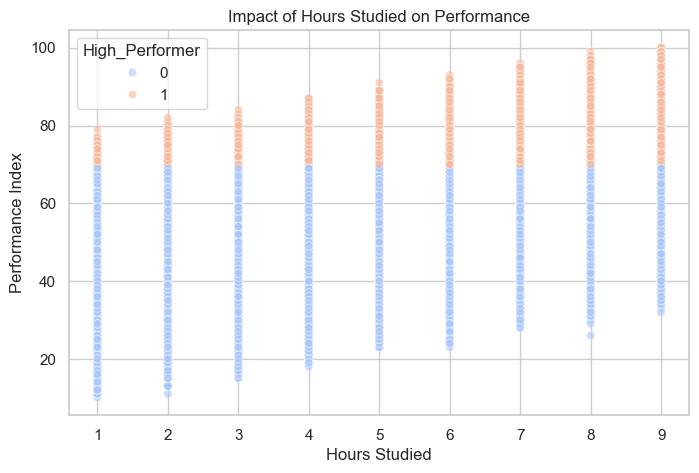

In [ ]:
# Set the style for our graphs to make them look nice
sns.set_theme(style="whitegrid")

# Create a scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='Hours Studied', 
    y='Performance Index', 
    hue='High_Performer', # Color the dots based on if they are high performers
    palette='coolwarm',   # Use a blue-to-red color scheme
    alpha=0.6             # Make dots slightly transparent to see overlapping
)

# Add titles and labels
plt.title('Impact of Hours Studied on Performance')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')

# Show the graph
plt.show()

## Splitting the Data (Train/Test Split)

In [ ]:
print("--- Preparing Data ---")

# 1. Define our Inputs (X)
# We use all columns EXCEPT the ones we are trying to predict
X = df[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']]

# 2. Define our Outputs (y)
y_linear = df['Performance Index']   # For Linear Regression (Number 1-100)
y_logistic = df['High_Performer']    # For Logistic Regression (1 or 0)

# 3. Split the data for Linear Regression (80% for training, 20% for testing)
X_train, X_test, y_train_lin, y_test_lin = train_test_split(X, y_linear, test_size=0.2, random_state=42)

# 4. Split the data for Logistic Regression (same X , but different y)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

print(f"Total students: {len(X)}")
print(f"Students used for training: {len(X_train)}")
print(f"Students saved for the 'final exam' (testing): {len(X_test)}")

--- Preparing Data ---
Total students: 10000
Students used for training: 8000
Students saved for the 'final exam' (testing): 2000


## Training the Linear Regression Model

In [ ]:
# 1. Create the model (the "brain")
linear_model = LinearRegression()

# 2. Train the model using the training data
# This is where the math happens! It figures out the relationship between X and y.
print("Training Linear Regression model...")
linear_model.fit(X_train, y_train_lin)

# 3. Test the model to see how good it is
# The score() function for Linear Regression returns the "R-squared" value.
# 1.0 is perfect prediction, 0.0 is terrible.
accuracy_score = linear_model.score(X_test, y_test_lin)

print("Training Complete!")
print(f"Linear Regression Score (R-squared): {accuracy_score * 100:.2f}%")

Training Linear Regression model...
Training Complete!
Linear Regression Score (R-squared): 98.87%


## Training the Logistic Regression Model

In [ ]:
# 1. Create the model
logistic_model = LogisticRegression()

# 2. Train the model using the training data (notice we use y_train_log here)
print("Training Logistic Regression model...")
logistic_model.fit(X_train, y_train_log)

# 3. Test the model
# For Logistic Regression, score() returns the standard Accuracy (percentage of correct guesses).
accuracy = logistic_model.score(X_test, y_test_log)

print("Training Complete!")
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Training Logistic Regression model...
Training Complete!
Logistic Regression Accuracy: 97.80%


## Save the Models in your Notebook

In [ ]:
# Save both models to files
joblib.dump(linear_model, 'models/linear_model.pkl')
joblib.dump(logistic_model, 'models/logistic_model.pkl')

print("Models saved successfully to the 'models' folder!")

Models saved successfully to the 'models' folder!
